In [1]:
import pandas as pd
import numpy as np
import os

# Column names
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

# ======================
# Load UCI datasets
# ======================
uci_path = r"C:\Users\Pooja Dhingiya\Downloads\heart+disease"

cleveland = pd.read_csv(os.path.join(uci_path, "processed.cleveland.data"), names=columns)
hungarian = pd.read_csv(os.path.join(uci_path, "processed.hungarian.data"), names=columns)
switzerland = pd.read_csv(os.path.join(uci_path, "processed.switzerland.data"), names=columns)
va = pd.read_csv(os.path.join(uci_path, "processed.va.data"), names=columns)

# Merge UCI
uci_merged = pd.concat([cleveland, hungarian, switzerland, va], ignore_index=True)

# Replace '?' with NaN
uci_merged.replace("?", np.nan, inplace=True)

# Convert to numeric
uci_merged = uci_merged.apply(pd.to_numeric)

# Convert target (1-4 → 1)
uci_merged["target"] = uci_merged["target"].apply(lambda x: 1 if x > 0 else 0)

# ======================
# Load Second Dataset
# ======================
second_dataset = pd.read_csv(r"C:\Users\Pooja Dhingiya\Downloads\archive (1)\heart.csv")

# Convert target if needed
second_dataset["target"] = second_dataset["target"].apply(lambda x: 1 if x > 0 else 0)

# ======================
# Merge Everything
# ======================
final_dataset = pd.concat([uci_merged, second_dataset], ignore_index=True)

# Handle missing values (recommended)
final_dataset.fillna(final_dataset.median(), inplace=True)

# Check final shape
print("Final dataset shape:", final_dataset.shape)

# Check class distribution
print("\nClass distribution:")
print(final_dataset["target"].value_counts())

# Save merged dataset
final_dataset.to_csv("final_merged_dataset.csv", index=False)

print("\nMerged dataset saved successfully!")


Final dataset shape: (1945, 14)

Class distribution:
target
1    1035
0     910
Name: count, dtype: int64

Merged dataset saved successfully!


In [2]:
print(second_dataset.columns)


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')


In [3]:
df = pd.read_csv("final_merged_dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1945 entries, 0 to 1944
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1945 non-null   float64
 1   sex       1945 non-null   float64
 2   cp        1945 non-null   float64
 3   trestbps  1945 non-null   float64
 4   chol      1945 non-null   float64
 5   fbs       1945 non-null   float64
 6   restecg   1945 non-null   float64
 7   thalach   1945 non-null   float64
 8   exang     1945 non-null   float64
 9   oldpeak   1945 non-null   float64
 10  slope     1945 non-null   float64
 11  ca        1945 non-null   float64
 12  thal      1945 non-null   float64
 13  target    1945 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 212.9 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000
mean,53.997429,0.739846,2.033933,131.793316,224.368123,0.149614,0.564524,143.881234,0.350643,0.971465,1.604113,0.504884,3.109512,0.532134
std,9.249763,0.438831,1.515313,17.961220,86.914190,0.356785,0.674397,24.697320,0.477294,1.125044,0.616628,0.903299,1.491691,0.499095
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,201.000000,0.000000,0.000000,126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,2.000000,130.000000,234.000000,0.000000,0.000000,146.000000,0.000000,0.600000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,271.000000,0.000000,1.000000,162.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


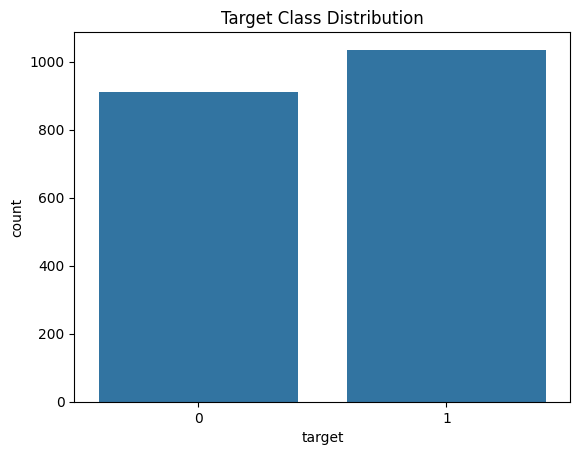

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='target', data=df)
plt.title("Target Class Distribution")
plt.show()

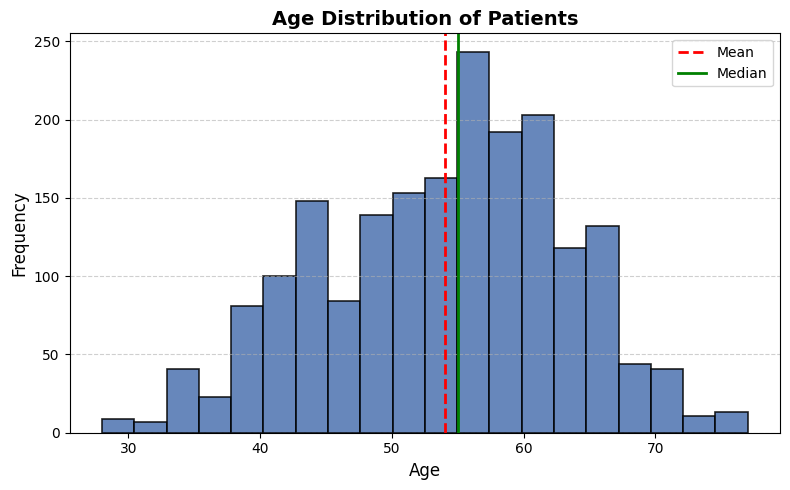

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    df['age'],
    bins=20,
    color='#4C72B0',        # Attractive blue
    edgecolor='black',      # Clear boundaries
    linewidth=1.2,
    alpha=0.85
)

# Add mean & median lines
plt.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(df['age'].median(), color='green', linestyle='-', linewidth=2, label='Median')

plt.title("Age Distribution of Patients", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

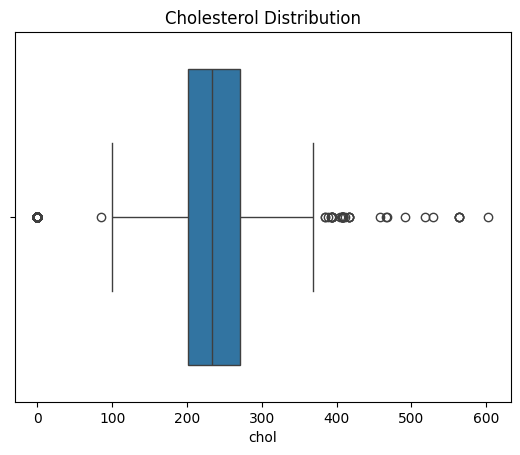

In [8]:
sns.boxplot(x=df['chol'])
plt.title("Cholesterol Distribution")
plt.show()

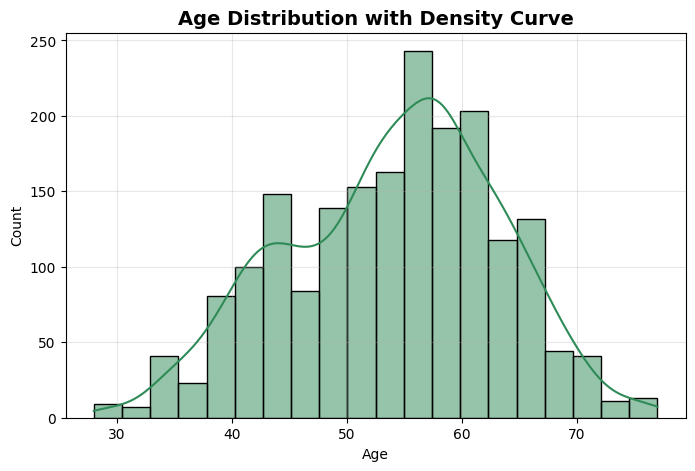

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    color="#2E8B57",
    edgecolor='black'
)

plt.title("Age Distribution with Density Curve", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(alpha=0.3)

plt.show()

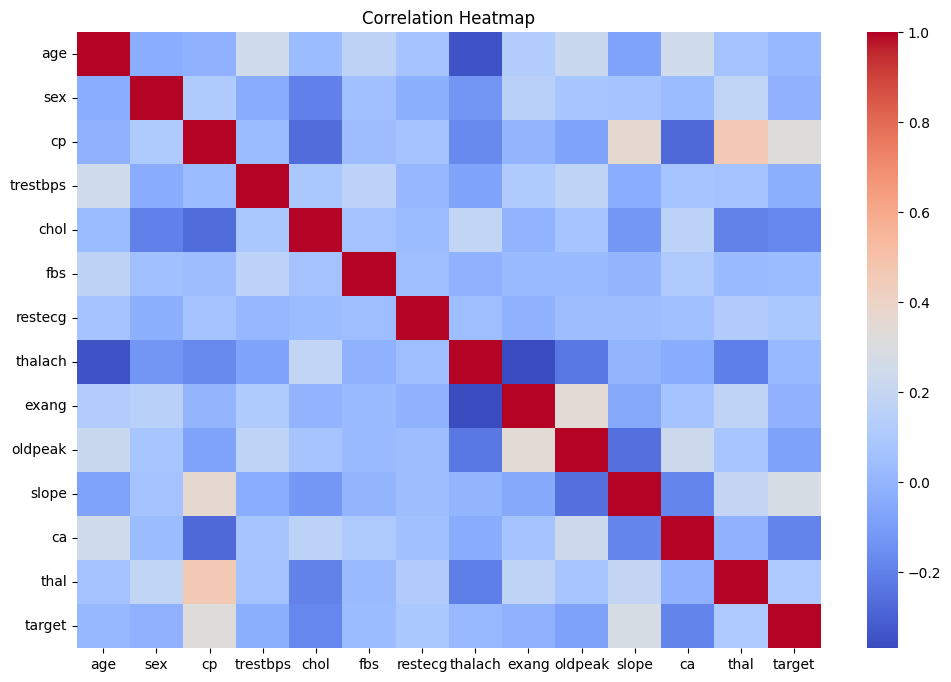

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
# Check missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
df["target"].value_counts()

target
1    1035
0     910
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1556, 13)
Testing shape: (389, 13)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [62]:
lr_pred = lr.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6915167095115681
              precision    recall  f1-score   support

           0       0.68      0.65      0.66       182
           1       0.70      0.72      0.71       207

    accuracy                           0.69       389
   macro avg       0.69      0.69      0.69       389
weighted avg       0.69      0.69      0.69       389



In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91       182
           1       0.90      0.96      0.93       207

    accuracy                           0.92       389
   macro avg       0.93      0.92      0.92       389
weighted avg       0.92      0.92      0.92       389



In [17]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [61]:
svm_pred = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8791773778920309
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       182
           1       0.86      0.92      0.89       207

    accuracy                           0.88       389
   macro avg       0.88      0.88      0.88       389
weighted avg       0.88      0.88      0.88       389



In [18]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Logistic Regression: 0.6915167095115681
Random Forest: 0.922879177377892
SVM: 0.8791773778920309


In [53]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_pred)

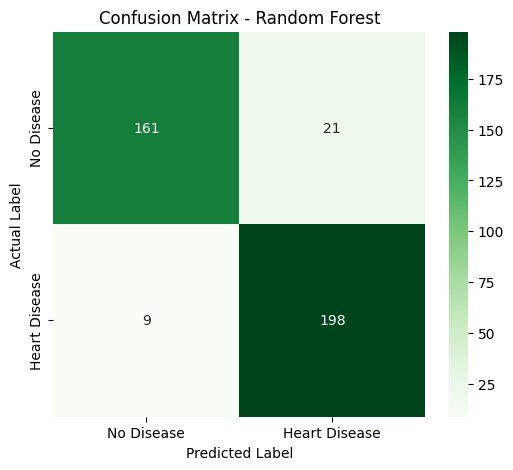

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm_rf, 
            annot=True, 
            fmt="d", 
            cmap="Greens",
            xticklabels=["No Disease", "Heart Disease"],
            yticklabels=["No Disease", "Heart Disease"])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

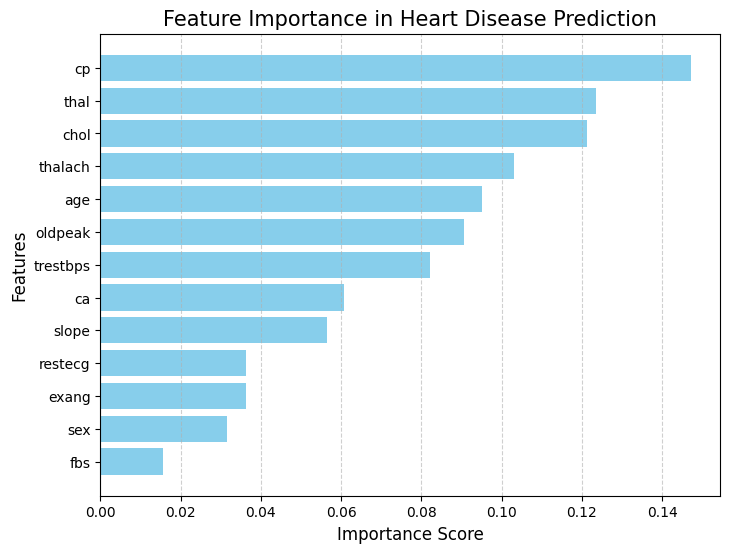

In [23]:
importance = rf.feature_importances_
features = X.columns

# Sort features by importance
indices = np.argsort(importance)

plt.figure(figsize=(8,6))

plt.barh(range(len(indices)), importance[indices], color="skyblue")

plt.yticks(range(len(indices)), [features[i] for i in indices])

plt.title("Feature Importance in Heart Disease Prediction", fontsize=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

In [24]:
def predict_heart_disease(data):
    data_scaled = scaler.transform([data])   # IMPORTANT
    prediction = ensemble_model.predict(data_scaled)
    
    return "Heart Disease Detected" if prediction == 1 else "No Heart Disease"

In [25]:
sample_patient = [52, 1, 2, 130, 250, 0, 1, 170, 0, 1.2, 2, 0, 2]

predict_heart_disease(sample_patient)

C:\Users\Pooja Dhingiya\heart_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Heart Disease Detected'

In [26]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Ensemble Model Accuracy:", accuracy_score(y_test, ensemble_pred))

Logistic Regression Accuracy: 0.6915167095115681
Random Forest Accuracy: 0.922879177377892
SVM Accuracy: 0.8791773778920309
Ensemble Model Accuracy: 0.8920308483290489


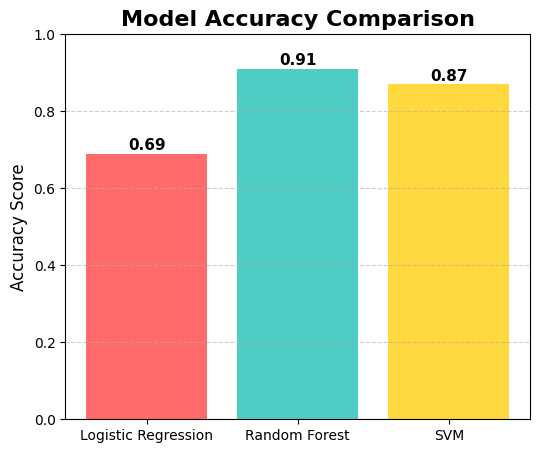

In [42]:
import matplotlib.pyplot as plt

models = ['Logistic Regression','Random Forest','SVM']
accuracy = [0.69,0.91,0.87]

plt.figure(figsize=(6,5))

bars = plt.bar(models, accuracy, 
               color=['#FF6B6B','#4ECDC4','#FFD93D'])

plt.title("Model Accuracy Comparison", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f"{height:.2f}",
             ha='center',
             fontsize=11,
             fontweight='bold')

plt.show()

In [19]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('svm', svm)
    ],
    voting='hard'
)

ensemble_model.fit(X_train_scaled, y_train)

ensemble_pred = ensemble_model.predict(X_test_scaled)

In [64]:
vote_pred = ensemble_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

print("Voting Accuracy:", accuracy_score(y_test, vote_pred))
print(classification_report(y_test, vote_pred))

Voting Accuracy: 0.8920308483290489
              precision    recall  f1-score   support

           0       0.93      0.84      0.88       182
           1       0.87      0.94      0.90       207

    accuracy                           0.89       389
   macro avg       0.90      0.89      0.89       389
weighted avg       0.89      0.89      0.89       389



In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_scaled, y_train)

gb_pred = gb.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.87146529562982


In [66]:
from sklearn.metrics import accuracy_score, classification_report

print("\nClassification Report (Gradient Boosting):\n")
print(classification_report(y_test, gb_pred))


Classification Report (Gradient Boosting):

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       182
           1       0.87      0.89      0.88       207

    accuracy                           0.87       389
   macro avg       0.87      0.87      0.87       389
weighted avg       0.87      0.87      0.87       389



In [29]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier()
ada.fit(X_train_scaled, y_train)

ada_pred = ada.predict(X_test_scaled)

print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))

AdaBoost Accuracy: 0.8123393316195373


In [67]:
from sklearn.metrics import accuracy_score, classification_report

print("\nClassification Report (AdaBoost):\n")
print(classification_report(y_test, ada_pred))


Classification Report (AdaBoost):

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       182
           1       0.81      0.85      0.83       207

    accuracy                           0.81       389
   macro avg       0.81      0.81      0.81       389
weighted avg       0.81      0.81      0.81       389



In [30]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[('rf', rf), ('svm', svm)],
    final_estimator=LogisticRegression()
)

stack.fit(X_train_scaled, y_train)

stack_pred = stack.predict(X_test_scaled)

print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))

Stacking Accuracy: 0.9177377892030848


In [56]:
stacking = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression()
)

stacking.fit(X_train_scaled, y_train)

stack_pred = stacking.predict(X_test_scaled)

In [57]:
stacking.fit(X_train, y_train)

C:\Users\Pooja Dhingiya\heart_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Pooja Dhingiya\heart_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('svm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inver

In [58]:
y_pred = stacking.predict(X_test)

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       182
           1       0.91      0.94      0.92       207

    accuracy                           0.92       389
   macro avg       0.92      0.91      0.91       389
weighted avg       0.92      0.92      0.92       389



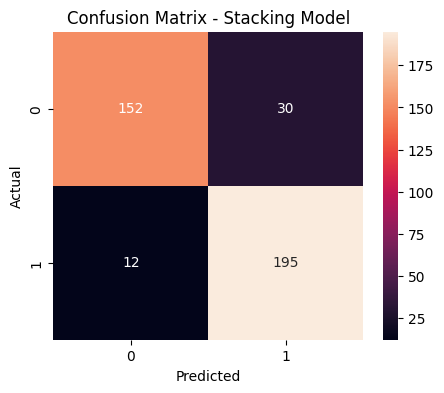

In [60]:


plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Model")

plt.show()

In [33]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","SVM","Voting","Gradient Boosting","AdaBoost","Stacking"],
    "Accuracy": [0.69,0.92,0.87,0.89,0.87,0.81,0.91]
})

print(results)

                 Model  Accuracy
0  Logistic Regression      0.69
1        Random Forest      0.92
2                  SVM      0.87
3               Voting      0.89
4    Gradient Boosting      0.87
5             AdaBoost      0.81
6             Stacking      0.91


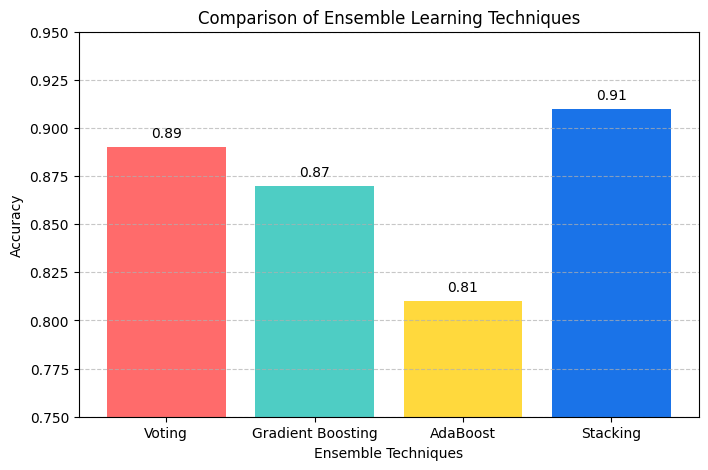

In [41]:
ensemble_results = {
    "Voting": 0.89,
    "Gradient Boosting": 0.87,
    "AdaBoost": 0.81,
    "Stacking": 0.91
}

models = list(ensemble_results.keys())
accuracy = list(ensemble_results.values())

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracy,color=['#FF6B6B','#4ECDC4','#FFD93D','#1A73E8'])

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2f}", ha='center')

plt.xlabel("Ensemble Techniques")
plt.ylabel("Accuracy")
plt.title("Comparison of Ensemble Learning Techniques")

plt.ylim(0.75, 0.95)  # better zoom

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

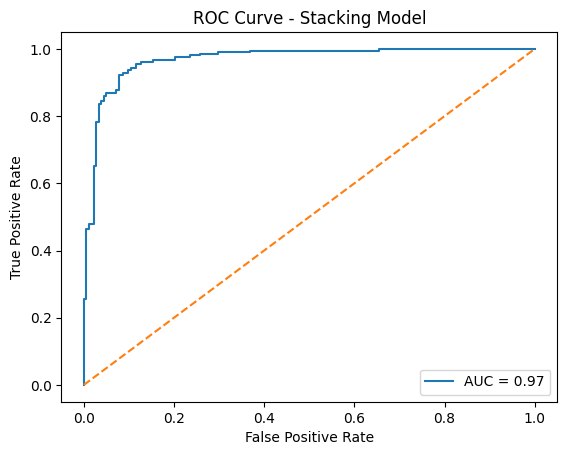

In [51]:
from sklearn.metrics import roc_curve, auc

y_prob = stacking.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Model")

plt.legend()
plt.show()

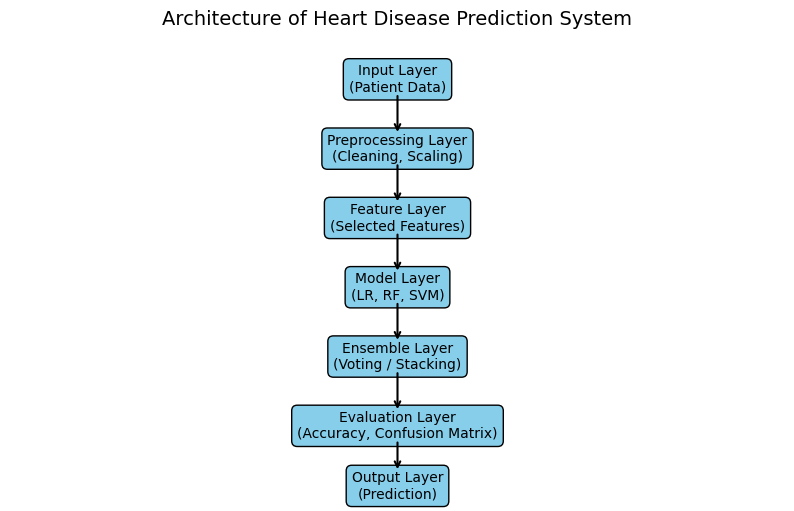

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

# Hide axes
ax.axis('off')

# Define layer positions
layers = [
    ("Input Layer\n(Patient Data)", 0.9),
    ("Preprocessing Layer\n(Cleaning, Scaling)", 0.75),
    ("Feature Layer\n(Selected Features)", 0.6),
    ("Model Layer\n(LR, RF, SVM)", 0.45),
    ("Ensemble Layer\n(Voting / Stacking)", 0.3),
    ("Evaluation Layer\n(Accuracy, Confusion Matrix)", 0.15),
    ("Output Layer\n(Prediction)", 0.02)
]

# Draw boxes
for text, y in layers:
    ax.text(0.5, y, text, ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="skyblue", ec="black"),
            fontsize=10)

# Draw arrows
for i in range(len(layers)-1):
    ax.annotate('', xy=(0.5, layers[i+1][1]+0.03),
                xytext=(0.5, layers[i][1]-0.03),
                arrowprops=dict(arrowstyle='->', lw=1.5))

plt.title("Architecture of Heart Disease Prediction System", fontsize=14)
plt.show()

In [36]:
import pickle

pickle.dump(ensemble_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [37]:
model = pickle.load(open("model.pkl", "rb"))
scaler_model = pickle.load(open("scaler.pkl", "rb"))

In [38]:
import os
print(os.getcwd())

C:\Users\Pooja Dhingiya\PRJ 3
